# Figures

In [1]:
0

0

In [2]:
import sys
import os
import gc
import networkx as nx
import numpy as np
import pandas as pd
import tqdm

In [3]:
import anndata as ad
import scanpy as sc
# import scvelo as scv
# import cellrank as cr
# import scanpy.external as sce

# scv.settings.verbosity = 3
# cr.settings.verbosity = 2
# sc.settings.verbose = 3

In [4]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"
sys.path.append(working_directory)

sys.path.append("/Users/kemalinecik/git_nosync/sctram/reproducibility/server_sync/experiments")
from incremental_training.helper.constants import metrics_scib, metric_direction_dict

from helper.get_hdca_trainings_with_paths import get_hdca_trainings_with_paths
from helper.pickle_operations import save_pickle_bundle, load_pickle_bundle
from helper.csv_operations import (
    harmonize_union_with_report,
    analyze_column_consistency,
    combine_dataframes_on_columns
)

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

2025-08-14 14:53:49.475 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /Users/kemalinecik/git_nosync/sctram/sctram/api/_defaults.yaml
2025-08-14 14:53:49.476 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc

import matplotlib.patheffects as path_effects
from adjustText import adjust_text
from matplotlib import gridspec
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects
import matplotlib.cm as cm
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
temp_move = "/Users/kemalinecik/Downloads/temp_move"

# Figure 

In [7]:
sctram_summary = pd.read_pickle(os.path.join(temp_move, "_experiment_development_atlas_sctram_summary_dataframe.pkl"))
scib_summary = pd.read_pickle(os.path.join(temp_move, "_experiment_development_atlas_scib_summary_dataframe.pkl"))

replacements = {
    "Pseudotime-based": "Cell Order\ncontinuity",
    "Embedding-based":  "Trajectory\ndominance",
    "Adjacency-based":  "Topology\nconservation",
    "Bio conservation":  "Biological\nconservation",
    "Batch correction":  "Batch\ncorrection",
}

summary = pd.concat([scib_summary, sctram_summary], keys=["scIB", "scTRAM"], axis=0)
summary.index.names = ["Source", "Metric Group"]
summary.columns.name = "Representation"
new_index_tuples = [
    ("Aggregate score", metric.split("Total ")[1]) if metric.startswith("Total ") else (src, metric) for src, metric in summary.index
]
summary.index = pd.MultiIndex.from_tuples(new_index_tuples, names=summary.index.names)

weights = {  # just provisional for now
    "scTRAM": 0.5,
    "scIB": 0.5,
}
row_ts = summary.loc[("Aggregate score", "scTRAM")]
row_si = summary.loc[("Aggregate score", "scIB")]
combined = weights["scTRAM"] * row_ts + weights["scIB"] * row_si
combined_df = pd.DataFrame(combined).T
combined_df.index = pd.MultiIndex.from_tuples([("Aggregate score", "Total")], names=summary.index.names)
summary = pd.concat([summary, combined_df])

summary = summary.sort_index(ascending=False)
summary = summary.sort_values(by=[("Aggregate score", "Total")], axis=1, ascending=False).astype(np.float64)

summary.rename(index=replacements, level="Metric Group", inplace=True)
summary_T = summary.T
summary

Representation                                scVI    scPoli    TarDis  \
Source          Metric Group                                             
scTRAM          Cell Order\ncontinuity    0.496894  0.363873  0.307523   
                Trajectory\ndominance     0.361357  0.271870  0.251885   
                Topology\nconservation    0.407202  0.399457  0.324503   
scIB            Biological\nconservation  0.538829  0.472530  0.500685   
                Batch\ncorrection         0.596689  0.574599  0.595137   
Aggregate score scTRAM                    0.426593  0.359799  0.304428   
                scIB                      0.561973  0.513357  0.538466   
                Total                     0.494283  0.436578  0.421447   

Representation                                 PCA   Harmony  Scanoroma  
Source          Metric Group                                             
scTRAM          Cell Order\ncontinuity    0.339600  0.201584   0.201729  
                Trajectory\ndominance     0.310389  0.265343   0.278251  
                Topology\nconservation    0.335616  0.237864   0.241379  
scIB            Biological\nconservation  0.556670  0.508973   0.533119  
                Batch\ncorrection         0.375922  0.511799   0.323021  
Aggregate score scTRAM                    0.332733  0.226760   0.229799  
                scIB                      0.484371  0.510104   0.449080  
                Total                     0.408552  0.368432   0.339440

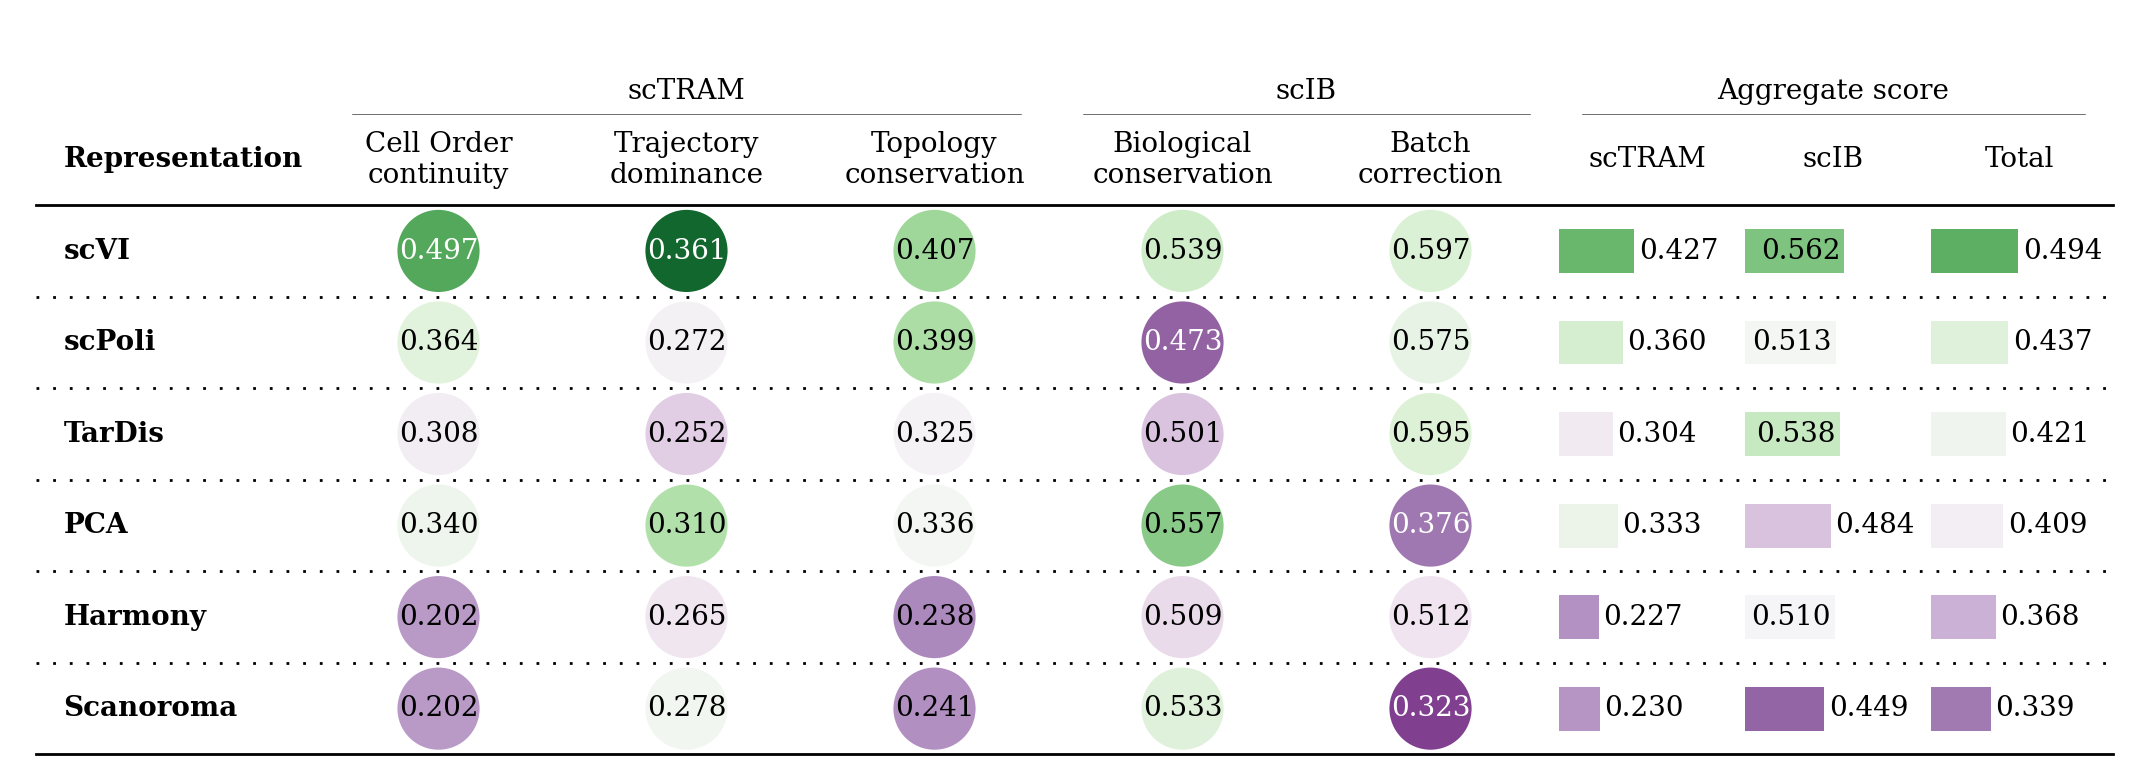

In [8]:
df_plot = summary_T.reset_index().copy()
df_plot_dict = {f"{lvl0}\n{lvl1}": (lvl0, lvl1) for (lvl0, lvl1) in df_plot.columns}
df_plot.columns = [f"{lvl0}\n{lvl1}" for (lvl0, lvl1) in df_plot.columns]

cmap_fn = lambda col_data: normed_cmap(col_data, cmap=cm.PRGn, num_stds=2.5)

col_defs = []
for col in df_plot.columns:
    # Create a “normalized color map” for this column:
    lvl0, lvl1 = df_plot_dict[col]
    if lvl0 == "Aggregate score" or lvl0 == "Representation":
        continue
    cmap = cmap_fn(df_plot[col])

    cd = ColumnDefinition(
        name=col,  # Must exactly match the flattened column name in df_plot
        width=0.4,  # width of each column in inches (tweak as needed)
        cmap=cmap,  # cell background colormap (normed by this column’s values)
        text_cmap=cmap,  # text color also follows same colormap
        textprops={
            "ha": "center",
            "bbox": {"boxstyle": "circle", "pad": 0},
        },
        group=lvl0,
        title=lvl1,
        formatter="{:.3f}".format,  # three decimal places
    )
    col_defs.append(cd)

i = 0
for col in df_plot.columns:
    # Create a “normalized color map” for this column:
    lvl0, lvl1 = df_plot_dict[col]
    if lvl0 != "Aggregate score" or lvl0 == "Representation":
        continue
    cmap = cmap_fn(df_plot[col])
    i += 1

    c_min = min(df_plot[col])
    c_max = max(df_plot[col])
    cmap = cmap_fn(df_plot[col])

    cd = ColumnDefinition(
        name=col,
        width=0.3,
        plot_fn=bar,
        plot_kw={
            "cmap": cmap, #cm.YlGnBu,
            "plot_bg_bar": False,
            # "xlim": [c_min, c_max],
            "annotate": True,
            "height": 0.8,
            "formatter": "{:.3f}",
            "textprops": {"fontsize": 10}
        },
        group=lvl0,
        title=lvl1,
        border="left" if i == 0 else None,
    )
    col_defs.append(cd)

col_defs += [ColumnDefinition(name="Representation\n", title="Representation", width=0.45, textprops={"ha": "left", "weight": "bold"})]

# Allow to manipulate text post-hoc (in illustrator)
with mpl.rc_context({"svg.fonttype": "none"}):
    fig, ax = plt.subplots(figsize=(len(summary_T.columns) * 1.7, 3 + 0.3 * len(summary_T.index)))
    tab = Table(
        df_plot,
        cell_kw={
            "linewidth": 0,
            "edgecolor": "k",
        },
        row_dividers=True,
        footer_divider=True,
        textprops={"fontsize": 10, "ha": "center"},
        row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
        col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
        column_border_kw={"linewidth": 1, "linestyle": "-"},
        column_definitions=col_defs,
        # even_row_color="#f7f9fa",
        # odd_row_color="#edf3f8",
        ax=ax,
        index_col="Representation\n",
    ).autoset_fontcolors(colnames=df_plot.columns)

    plt.savefig("/Users/kemalinecik/Downloads/fig2fig/table.pdf")

# Supplementary

In [10]:
def rank_metrics(df, metric_direction_dict, metric_index_pos, method='min'):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():
        
        metric = indices[metric_index_pos]
        direction = metric_direction_dict.get(metric)
        
        if direction not in ('increasing', 'decreasing'):
            raise ValueError            
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)

        # ranks = 1 - pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)
        
        ranked_df.loc[indices] = ranks.astype('Float64')
    return ranked_df

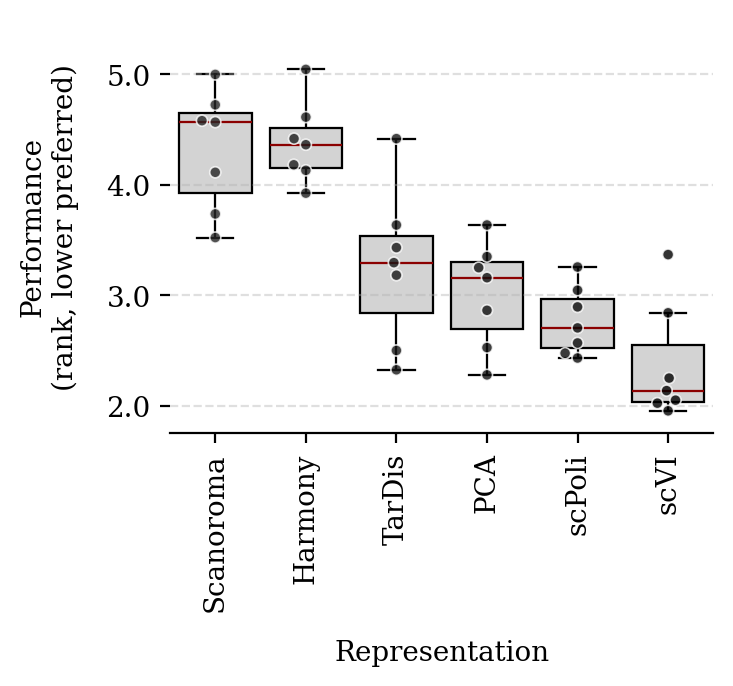

In [14]:
result_df = pd.read_pickle(os.path.join(temp_move, "_experiment_development_atlas_result_df_dataframe.pkl"))
df_pivot = result_df.pivot(index=["trajectory_class", 'trajectory', 'path', 'metric'], columns='representation', values='score')
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_pivot_rank_mean = df_pivot_rank.groupby(level=1).mean()
rename_model_name_dict = {
    'pca': 'PCA',
    'X_pca': 'PCA',
    'harmony': 'Harmony',
    'invae': 'inVAE',
    'scanvi': 'scANVI',
    'scvi': 'scVI',
    'scpoli': 'scPoli',
    'scanoroma': 'Scanoroma',
    'tardis_1': 'DELETE ME',
    'tardis_2': 'TarDis',
    'tardis': 'TarDis',
}
col_order = ['Scanoroma', 'Harmony', 'TarDis', 'PCA', 'scPoli', 'scVI']

def _(df):
    df = df.rename(columns=rename_model_name_dict)
    df = df[col_order]
    
    fig_height=4
    n_cols = df.shape[1]
    col_width = 0.7  # Width per column in inches
    fig_width = n_cols * col_width
    # fig_height = 8  # Fixed height for better vertical readability
    
    # Create figure with dynamic width
    plt.figure(figsize=(fig_width, fig_height))
    
    # Create boxplot with refined styling
    bp = sns.boxplot(data=df,
                     width=0.8,
                     showfliers=False,
                     boxprops=dict(facecolor='lightgray', edgecolor='black', linewidth=0.81),
                     whiskerprops=dict(color='black', linewidth=0.81),
                     medianprops=dict(color='darkred', linewidth=0.81),
                     capprops=dict(color='black', linewidth=0.81),
                     saturation=1,
                     zorder=1)
    
    # Add swarmplot with sophisticated aesthetics
    sp = sns.swarmplot(data=df,
                       size=4,
                       palette='dark:black',
                       edgecolor='white',
                       linewidth=0.6,
                       alpha=0.8,
                       marker='o',
                       zorder=2)
    
    # Enhance axis styling
    plt.xticks(rotation=90, ha='center', fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Representation', fontsize=10, labelpad=10)
    plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)
    
    plt.gca().set_ylim(1.75, 5.5)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Add light grid and adjust borders
    bp.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(left=True, trim=False)
    
    # Adjust layout with professional spacing
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.savefig("/Users/kemalinecik/Downloads/fig2fig/modelcomp_boxplot.pdf")
_(df_pivot_rank_mean)

In [16]:
df_pivot_rank_mean = df_pivot_rank.groupby(level=[0, 1]).mean()
df_pivot_rank_mean = df_pivot_rank_mean.rename(columns=rename_model_name_dict)
df_pivot_rank_mean = df_pivot_rank_mean[col_order]
df_long = df_pivot_rank_mean.reset_index().melt(id_vars=['trajectory_class', 'trajectory'], var_name='representation', value_name='score')

/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_17496/2428741622.py:11: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  bp = sns.barplot(
/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_17496/2428741622.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


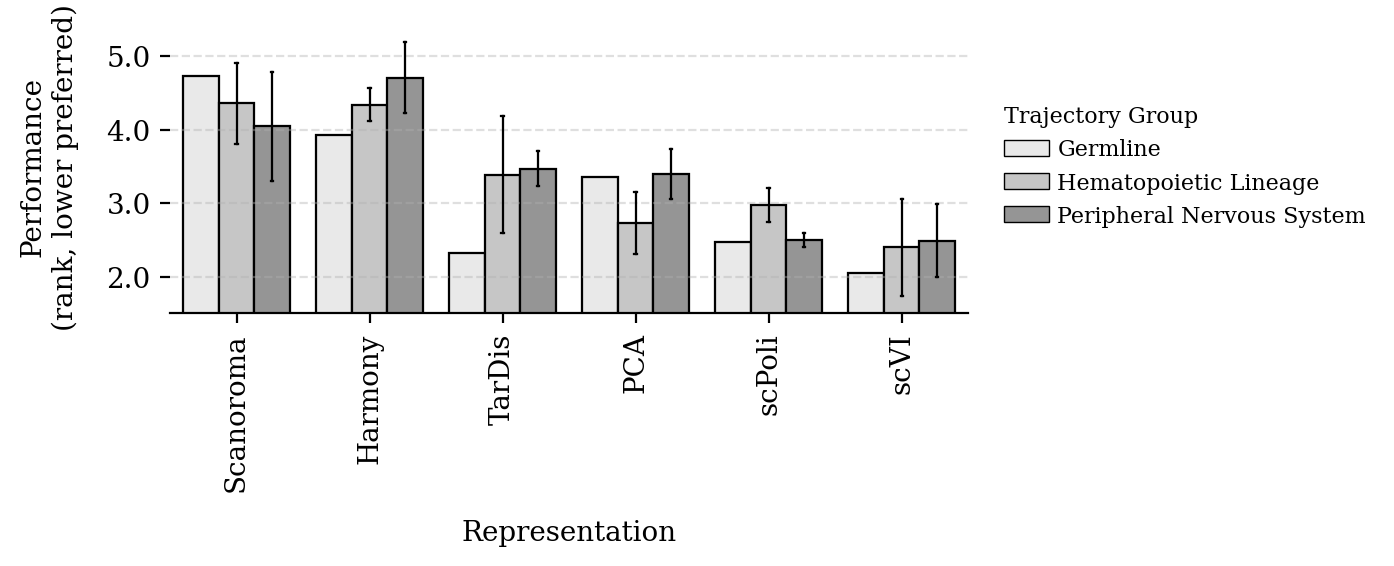

In [18]:
# match boxplot’s height & per-column width
fig_height = 3
n_cols = df_long["representation"].nunique()
col_width = 1.4
fig_width = n_cols * col_width
n_tc = len(np.unique(df_long["trajectory_class"]))

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=df_long,
    x="representation",
    y="score",
    hue="trajectory_class",
    palette=sns.color_palette("Greys", n_colors=n_tc+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Representation', fontsize=10, labelpad=10)
plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)

ax.set_ylim(1.5, 5.5)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    labels,
    title="Trajectory Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    alignment="left",
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("/Users/kemalinecik/Downloads/fig2fig/modelcomp_barplot1.pdf")


In [19]:
df_pivot_rank_mean = df_pivot_rank.groupby(level=[2, 1]).mean()
df_pivot_rank_mean = df_pivot_rank_mean.rename(columns=rename_model_name_dict)
df_pivot_rank_mean = df_pivot_rank_mean[col_order]
df_long = df_pivot_rank_mean.reset_index().melt(id_vars=['path', 'trajectory'], var_name='representation', value_name='score')

/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_17496/4106653059.py:16: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  bp = sns.barplot(
/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_17496/4106653059.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


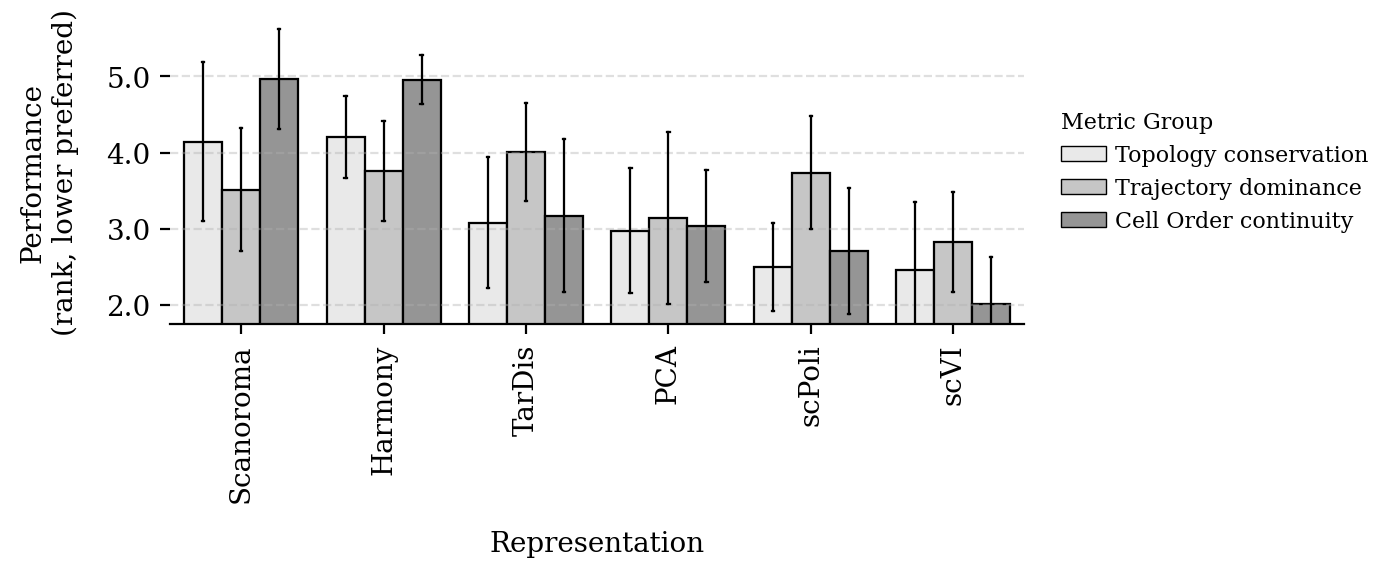

In [22]:
label_mapping = {
    "adjacency": 'Topology conservation',
    "embedding": 'Trajectory dominance',
    "pseudotime": 'Cell Order continuity',
}

# match boxplot’s height & per-column width
fig_height = 3
n_cols = df_long["representation"].nunique()
col_width = 1.4
fig_width = n_cols * col_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=df_long,
    x="representation",
    y="score",
    hue="path",
    palette=sns.color_palette("Greys", n_colors=len(label_mapping)+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Representation', fontsize=10, labelpad=10)
plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)

ax.set_ylim(1.75, 5.75)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_mapping.get(l, l) for l in labels]

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    new_labels,
    title="Metric Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    alignment="left",
    frameon=False,
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("/Users/kemalinecik/Downloads/fig2fig/modelcomp_barplot2.pdf")


# Figure 2

In [90]:
result_df_main = pd.read_pickle(os.path.join(temp_move, f"df_boots_fig2_calculations.pkl"))
(
    df_hdca_component_adata_paths,
    df_hdca_lvl3_adata_paths,
    out_df,
    ground_truth_trajectories,
    ground_truth_trajectories_annotation_level,
    trajectory_subset_dict
) = load_pickle_bundle(os.path.join(temp_move, "_experiment_development_atlas_helper_pickle_bundle.pkl"))

In [91]:
from math import sqrt

def rank_metrics(df, metric_direction_dict, metric_index_pos, method='min'):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():
        
        metric = indices[metric_index_pos]
        direction = metric_direction_dict.get(metric)
        
        if direction not in ('increasing', 'decreasing'):
            raise ValueError            
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)

        # ranks = 1 - pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)
        
        ranked_df.loc[indices] = ranks.astype('Float64')
    return ranked_df

def plot_trajectory(
    G,
    title="trajectory_name",
    figsize=None,
    font_size=10,
    node_size=300,
    node_color="#8DA0CB",  # Modern muted blue
    cmap="viridis",
    color_nodes_by_position=False,
    # Edge styling parameters
    edge_width=1,
    edge_color="gray",
    color_edges_by_weight=False,
    edge_weight_attribute="weight",
    edge_cmap="plasma",
    edge_vmin=None,
    edge_vmax=None,
    edge_colorbar=True,
    edge_labels=False,
    edge_label_format=".2f",
    edge_label_font_size=8,
    edge_label_color="black",
    edge_label_offset=None,
    # Layout parameters
    label_offset=None,
    title_y=1.02,
    layout_args="-Grankdir=LR -Gnodesep=0.25 -Granksep=0.25",
    file_name="blabla"
):
    
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args=layout_args)
    x_coords = [pos[node][0] for node in G.nodes()] if G.nodes() else []
    y_coords = [pos[node][1] for node in G.nodes()] if G.nodes() else []

    # Create actual figure with determined size
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    # Node coloring logic
    if color_nodes_by_position:
        try:
            min_x, max_x = min(x_coords), max(x_coords)
            color_vals = [(x - min_x) / (max_x - min_x) if max_x != min_x else 0.5 for x in x_coords]
            node_color = plt.get_cmap(cmap)(color_vals)
        except Exception as e:
            print(f"Warning: Positional node coloring failed - {e}. Using base color.")

    # Edge coloring logic
    if color_edges_by_weight:
        weights = [G[u][v].get(edge_weight_attribute, 1.0) for u, v in G.edges]
        
        # Separate NaN and valid weights
        valid_weights = [w for w in weights if not np.isnan(w)]
        if valid_weights:
            edge_vmin = edge_vmin if edge_vmin is not None else min(valid_weights)
            edge_vmax = edge_vmax if edge_vmax is not None else max(valid_weights)
            norm = mpl.colors.Normalize(vmin=edge_vmin, vmax=edge_vmax)
            cmap_edge = plt.get_cmap(edge_cmap)
            
            # Create edge colors, using gray with alpha=0.712 for NaN weights
            edge_colors = []
            edge_alphas = []
            for w in weights:
                if np.isnan(w):
                    edge_colors.append("lightgray")
                    edge_alphas.append(0.712)
                else:
                    edge_colors.append(cmap_edge(norm(w)))
                    edge_alphas.append(1.0)
            
            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_edge)
            sm.set_array(valid_weights)
        else:
            edge_colors = "lightgray"
            edge_alphas = 0.712
            sm = None
    else:
        edge_colors = edge_color
        edge_alphas = 1.0
        sm = None

    # Label positioning offsets
    if label_offset is None:
        label_offset = 0

    if edge_label_offset is None:
        edge_label_offset = 0

    # Calculate final label positions
    label_pos = {n: (x, y + label_offset) for n, (x, y) in pos.items()}

    # Draw nodes and edges
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=node_size, node_color=node_color, edgecolors="black", linewidths=0.8, alpha=1.0
    )

    node_radius = sqrt(node_size) / 2.0
    
    if color_edges_by_weight and isinstance(edge_alphas, list):
        # Draw edges individually when we have different alpha values
        for i, (u, v) in enumerate(G.edges()):
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=[(u, v)],
                ax=ax,
                edge_color=[edge_colors[i]],
                width=edge_width,
                alpha=edge_alphas[i],
                connectionstyle="arc3",
                arrows=False,
            )
    else:
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color=edge_colors,
            width=edge_width,
            alpha=edge_alphas if not isinstance(edge_alphas, list) else 1.0,
            connectionstyle="arc3",
            arrows=False,
        )

    # Edge label placement
    if edge_labels:
        for u, v in G.edges():
            if edge_weight_attribute not in G[u][v]:
                continue
            weight = G[u][v][edge_weight_attribute]
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            dx, dy = x2 - x1, y2 - y1
            length = (dx**2 + dy**2) ** 0.5
            if length == 0:
                continue  # Skip self-loops
            # Calculate perpendicular offset position
            mid_x = (x1 + x2) / 2 + (dy / length) * edge_label_offset
            mid_y = (y1 + y2) / 2 - (dx / length) * edge_label_offset
            ax.text(
                mid_x,
                mid_y,
                f"{weight:{edge_label_format}}",
                fontsize=edge_label_font_size,
                color=edge_label_color,
                ha="center",
                va="center",
                # bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"),
            )

    # Edge weight colorbar
    if color_edges_by_weight and edge_colorbar and sm:
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.3, aspect=40, pad=0.05)
        cbar.set_label("Edge Weight", fontsize=font_size)
        cbar.ax.tick_params(labelsize=font_size - 2)

    fig.suptitle(title, y=title_y, fontsize=font_size + 2, fontweight="bold", color="#333333")

    # Final layout adjustments
    plt.subplots_adjust(
        left=0.03, right=0.97, top=0.97, bottom=0.15 if (color_edges_by_weight and edge_colorbar) else 0.03
    )
    ax.set_axis_off()
    plt.margins(y=1)  # Add 20% margin on all sides
    plt.savefig(f"/Users/kemalinecik/Downloads/fig2fig/{file_name}.pdf")

In [92]:
for trajectory_focus, result_df in result_df_main.groupby('trajectory'):
    if trajectory_focus == "Haem_ref":
        decompose_method = "2"
        input_trajectories_path_litc = os.path.join(temp_move, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            lit = pickle.load(_file)
        break

df_edges = []
for ind, row in result_df.iterrows():
    trj = lit.get_trajectory(row["booted_trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)

df_edges_pivot = df_edges.pivot(index=['path', 'booted_trajectory', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='representation', values='score')
df_edges_pivot_rank = rank_metrics(df_edges_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()

In [93]:
df_edges_pivot_rank

representation                                                                                      harmony  \
path       booted_trajectory   trajectory metric                           from_cell   to_cell                
adjacency  Haem_ref_subgraph_0 Haem_ref   accuracy                         HSC_MPP     LMPP_MLP         1.0   
                                                                           LMPP_MLP    NK               1.0   
                                                                           NK          CYCLING_NK       1.0   
                                          average_shortest_path_difference HSC_MPP     LMPP_MLP         1.0   
                                                                           LMPP_MLP    NK               1.0   
...                                                                                                     ...   
pseudotime Haem_ref_subgraph_9 Haem_ref   r_squared_with_spline            LMPP_MLP    DN(early)_T      6.0   
                                          spearman_correlation             DN(early)_T DN(P)_T          5.0   
                                                                           LMPP_MLP    DN(early)_T      5.0   
                                          wasserstein_distance_pseudotime  DN(early)_T DN(P)_T          6.0   
                                                                           LMPP_MLP    DN(early)_T      6.0   

representation                                                                                      pca  \
path       booted_trajectory   trajectory metric                           from_cell   to_cell            
adjacency  Haem_ref_subgraph_0 Haem_ref   accuracy                         HSC_MPP     LMPP_MLP     1.0   
                                                                           LMPP_MLP    NK           1.0   
                                                                           NK          CYCLING_NK   1.0   
                                          average_shortest_path_difference HSC_MPP     LMPP_MLP     5.0   
                                                                           LMPP_MLP    NK           5.0   
...                                                                                                 ...   
pseudotime Haem_ref_subgraph_9 Haem_ref   r_squared_with_spline            LMPP_MLP    DN(early)_T  2.0   
                                          spearman_correlation             DN(early)_T DN(P)_T      2.0   
                                                                           LMPP_MLP    DN(early)_T  2.0   
                                          wasserstein_distance_pseudotime  DN(early)_T DN(P)_T      1.0   
                                                                           LMPP_MLP    DN(early)_T  1.0   

representation                                                                                      scanoroma  \
path       booted_trajectory   trajectory metric                           from_cell   to_cell                  
adjacency  Haem_ref_subgraph_0 Haem_ref   accuracy                         HSC_MPP     LMPP_MLP           1.0   
                                                                           LMPP_MLP    NK                 1.0   
                                                                           NK          CYCLING_NK         1.0   
                                          average_shortest_path_difference HSC_MPP     LMPP_MLP           3.0   
                                                                           LMPP_MLP    NK                 3.0   
...                                                                                                       ...   
pseudotime Haem_ref_subgraph_9 Haem_ref   r_squared_with_spline            LMPP_MLP    DN(early)_T        5.0   
                                          spearman_correlation             DN(early)_T DN(P)_T            6.0   
                                  

In [94]:
from scipy.stats import mannwhitneyu, binomtest, wilcoxon

def compare_scores_and_get_means(group):
    scpoli_scores = group['scpoli'].dropna()
    scvi_scores = group['scvi'].dropna()
    
    if len(scpoli_scores) < 2 or len(scvi_scores) < 2:
        raise ValueError
    
    #  since your “scores” are actually ranks (ordinal) for the same boot replicate per edge, you have paired, ordinal data.
    # Perform the Mann-Whitney U test
    # stat, p_value = mannwhitneyu(scpoli_scores, scvi_scores, alternative='two-sided')
    
    # Wilcoxon signed-rank — more power if the distribution of paired differences is roughly symmetric; handle ties with zero_method="pratt"
    method = 'exact' if len(scpoli_scores) <= 25 else 'approx'
    p_value = wilcoxon(scpoli_scores, scvi_scores, zero_method='pratt', alternative='two-sided', method=method).pvalue

    # Statistically different: return means.
    return pd.Series({
        'mean_scpoli': np.mean(scpoli_scores), 
        'mean_scvi': np.mean(scvi_scores),
        'p_value': p_value
    })

df_edges_pivot_rank_p = df_edges_pivot_rank.groupby(['from_cell', 'to_cell']).apply(compare_scores_and_get_means).reset_index()

alpha = 0.05 / len(df_edges_pivot_rank_p)
df_edges_pivot_rank_p['mean_scvi_final']   = np.where(df_edges_pivot_rank_p['p_value'] < alpha, df_edges_pivot_rank_p['mean_scvi'], np.nan)
df_edges_pivot_rank_p['mean_scpoli_final'] = np.where(df_edges_pivot_rank_p['p_value'] < alpha, df_edges_pivot_rank_p['mean_scpoli'], np.nan)
df_edges_pivot_rank_p

,from_cell,to_cell,mean_scpoli,mean_scvi,p_value,mean_scvi_final,mean_scpoli_final
0,ABT(ENTRY),CD4_T,2.940711,2.418972,4.472427e-07,2.418972,2.940711
1,ABT(ENTRY),CD8AA,2.839623,2.231132,8.219408e-08,2.231132,2.839623
2,ABT(ENTRY),CD8_T,3.041176,2.252941,8.787879e-09,2.252941,3.041176
3,ABT(ENTRY),CYCLING_T,2.834906,2.334906,6.001141e-05,2.334906,2.834906
4,ABT(ENTRY),TYPE_1_INNATE_T,2.834906,2.495283,5.249714e-03,NaN,NaN
5,ABT(ENTRY),TYPE_3_INNATE_T,2.882075,2.339623,1.474034e-05,2.339623,2.882075
6,CD4_T,TREG,3.023585,2.325472,2.045326e-09,2.325472,3.023585
7,CD8_T,TREG,3.041176,2.252941,8.787879e-09,2.252941,3.041176
8,CMP,DC,2.952153,2.650718,3.384503e-03,NaN,NaN
9,CMP,DC1,3.165354,2.669291,1.244083e-03,NaN,NaN


In [95]:
trj = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, False)
representations = ["scvi", "scpoli"]

for ind, row in df_edges_pivot_rank_p.iterrows():
    for repr in representations:
        trj[row["from_cell"]][row["to_cell"]][f"weight_{repr}"] = row[f"mean_{repr}_final"]

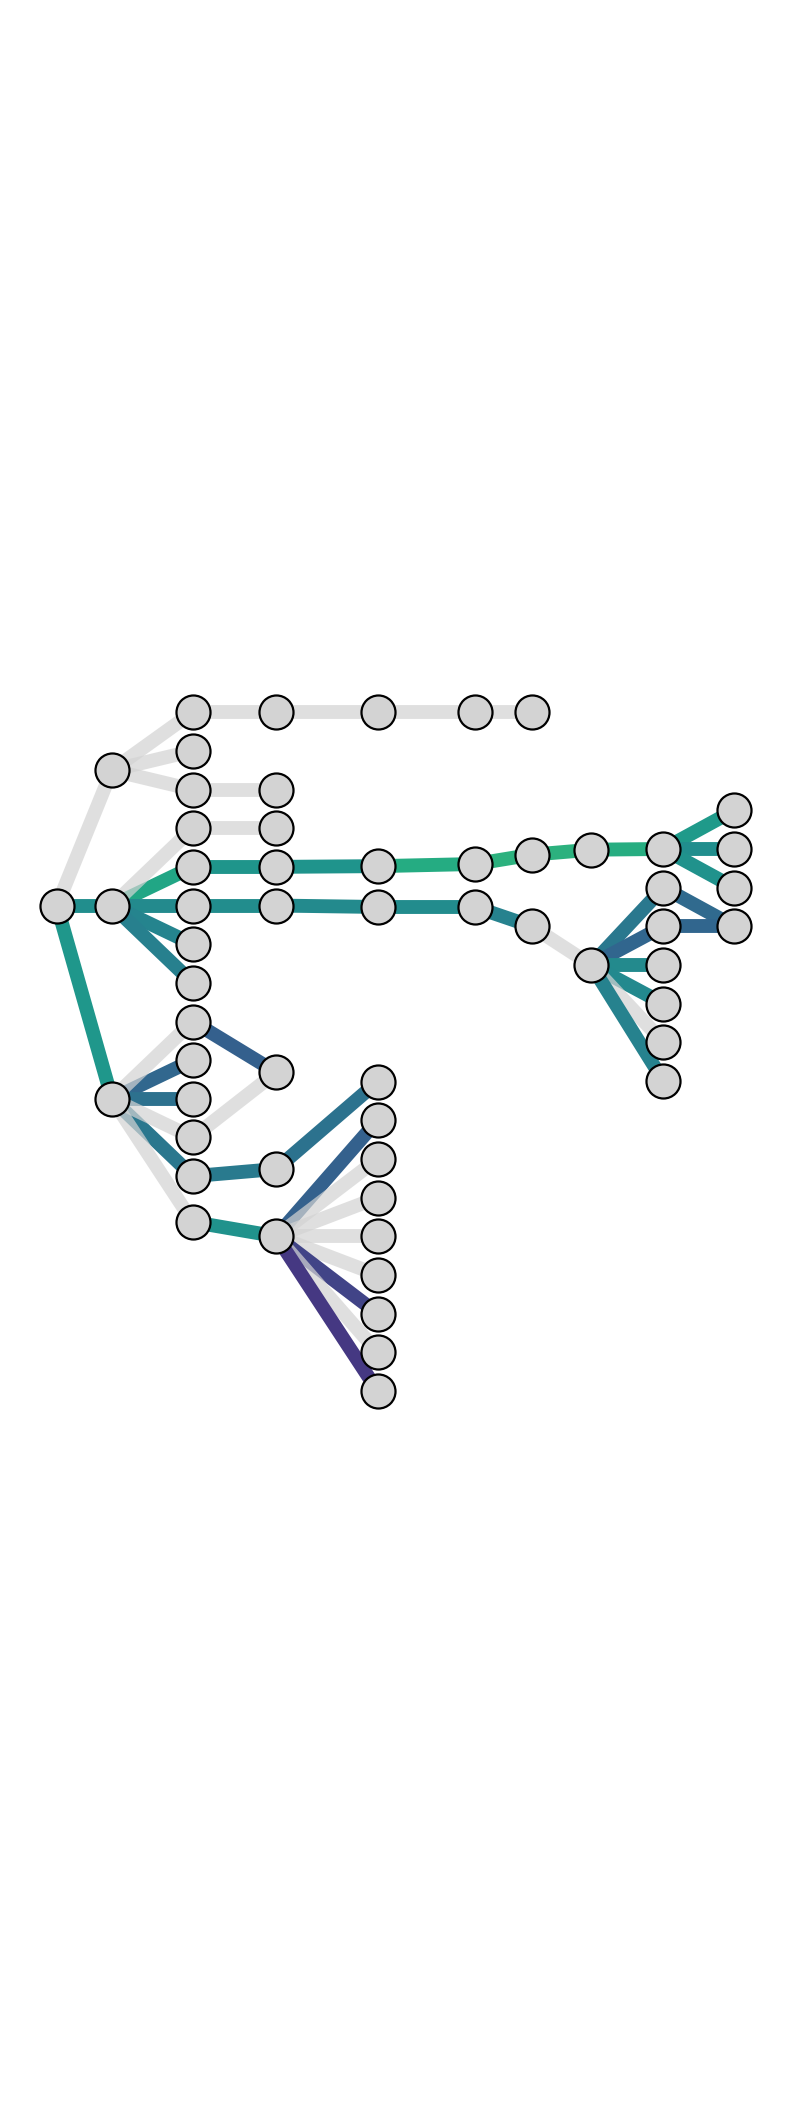

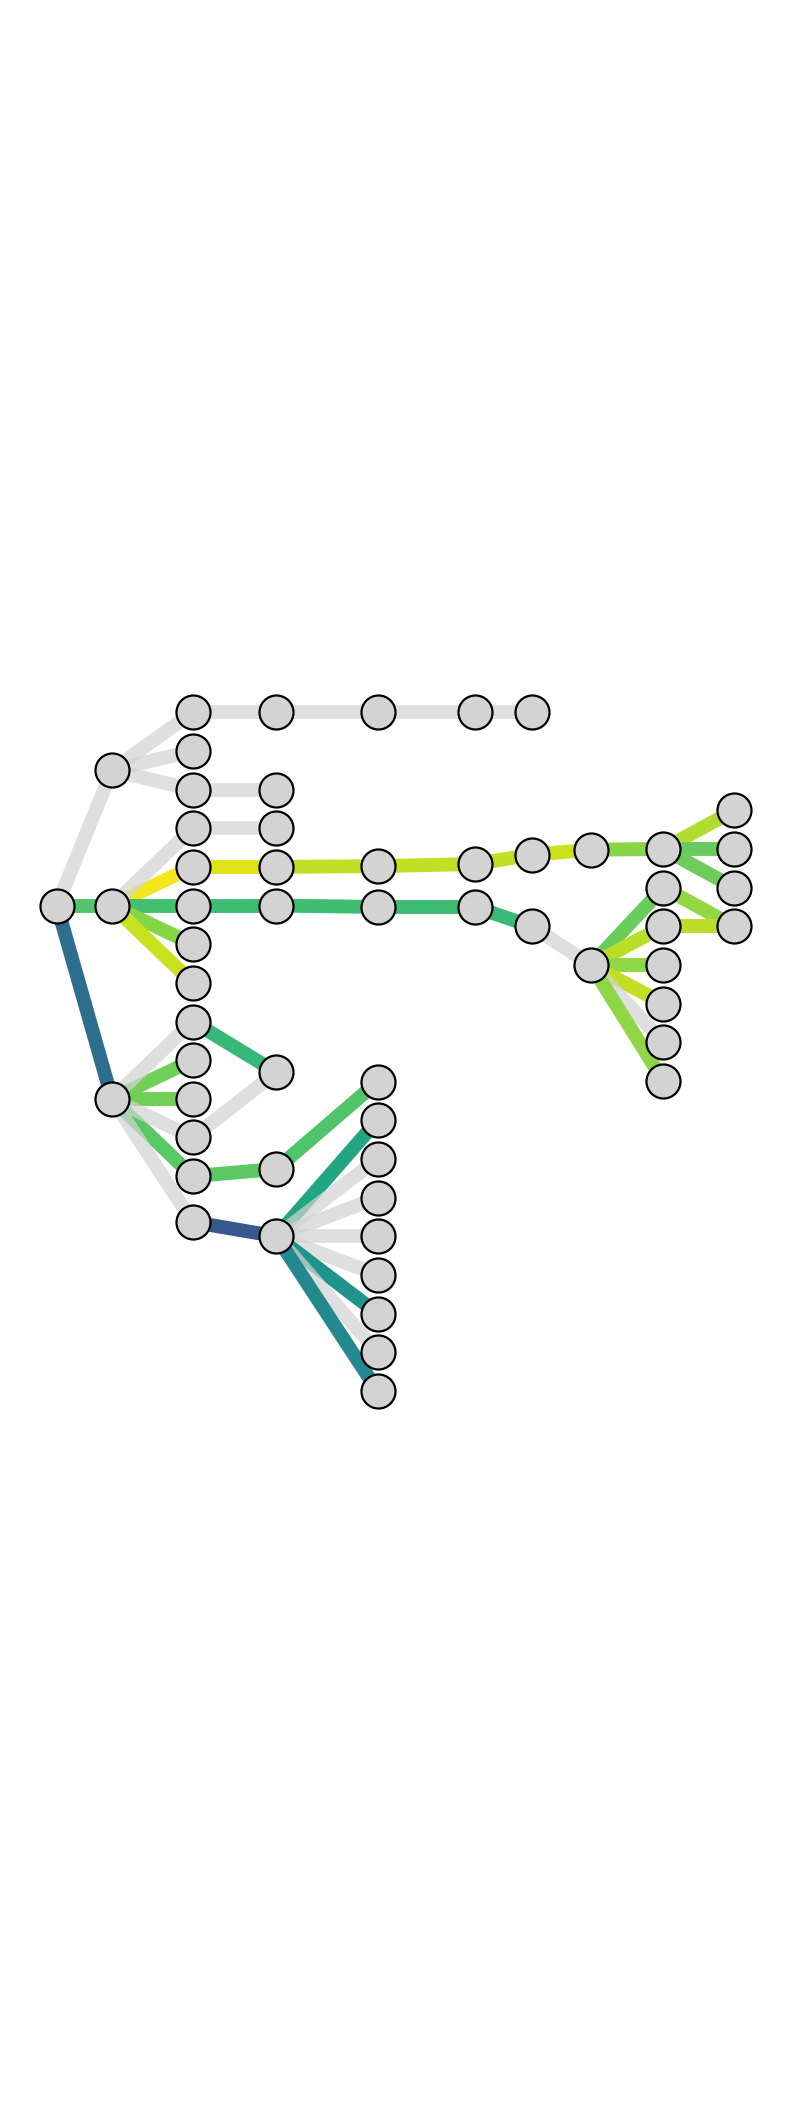

In [103]:
for i in ['weight_scpoli', 'weight_scvi']:
    plot_trajectory(
        trj, 
        figsize=(4, 11),
        edge_weight_attribute=i,
        title="", 
        edge_vmin=2.1,
        edge_vmax=3.5,
        color_edges_by_weight=True, 
        node_size=150, 
        node_color="lightgray", 
        edge_color='black',
        edge_width=5,
        edge_labels=False,
        edge_label_font_size=5,
        edge_cmap='viridis_r',
        edge_colorbar=False,
        file_name=f"{trajectory_focus}_{i}"
    )

In [104]:
for trajectory_focus, result_df in result_df_main.groupby('trajectory'):
    if trajectory_focus == "germline":
        decompose_method = "2"
        input_trajectories_path_litc = os.path.join(temp_move, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            lit = pickle.load(_file)
        break

df_edges = []
for ind, row in result_df.iterrows():
    trj = lit.get_trajectory(row["booted_trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)

df_edges_pivot = df_edges.pivot(index=['path', 'booted_trajectory', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='representation', values='score')
df_edges_pivot_rank = rank_metrics(df_edges_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()

df_edges_pivot_rank_p = df_edges_pivot_rank.groupby(['from_cell', 'to_cell']).apply(compare_scores_and_get_means).reset_index()

alpha = 0.05 / len(df_edges_pivot_rank_p)
df_edges_pivot_rank_p['mean_scvi_final']   = np.where(df_edges_pivot_rank_p['p_value'] < alpha, df_edges_pivot_rank_p['mean_scvi'], np.nan)
df_edges_pivot_rank_p['mean_scpoli_final'] = np.where(df_edges_pivot_rank_p['p_value'] < alpha, df_edges_pivot_rank_p['mean_scpoli'], np.nan)

trj = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, False)
representations = ["scvi", "scpoli"]

for ind, row in df_edges_pivot_rank_p.iterrows():
    for repr in representations:
        trj[row["from_cell"]][row["to_cell"]][f"weight_{repr}"] = row[f"mean_{repr}_final"]

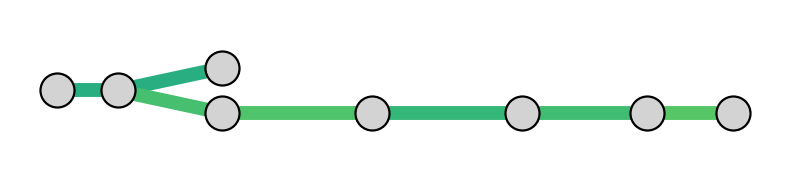

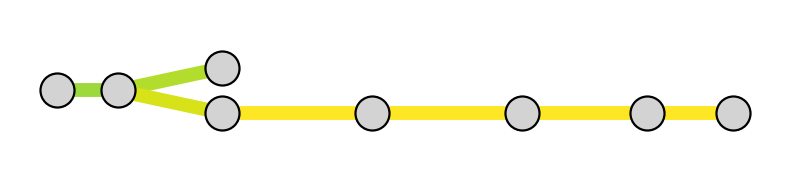

In [106]:
for i in ['weight_scpoli', 'weight_scvi']:
    plot_trajectory(
        trj, 
        figsize=(4, 0.75),
        edge_weight_attribute=i,
        title="", 
        edge_vmin=2.1,
        edge_vmax=3.5,
        color_edges_by_weight=True, 
        node_size=150, 
        node_color="lightgray", 
        edge_color='black',
        edge_width=5,
        edge_labels=False,
        edge_label_font_size=5,
        edge_cmap='viridis_r',
        edge_colorbar=False,
        file_name=f"{trajectory_focus}_{i}"
    )

In [114]:
def compare_scores_and_get_means(group):
    tardis_scores = group['tardis'].dropna()
    scvi_scores = group['scvi'].dropna()
    
    if len(tardis_scores) < 2 or len(scvi_scores) < 2:
        raise ValueError
    
    #  since your “scores” are actually ranks (ordinal) for the same boot replicate per edge, you have paired, ordinal data.
    # Perform the Mann-Whitney U test
    # stat, p_value = mannwhitneyu(tardis_scores, scvi_scores, alternative='two-sided')
    
    # Wilcoxon signed-rank — more power if the distribution of paired differences is roughly symmetric; handle ties with zero_method="pratt"
    method = 'exact' if len(tardis_scores) <= 25 else 'approx'
    p_value = wilcoxon(tardis_scores, scvi_scores, zero_method='pratt', alternative='two-sided', method=method).pvalue

    # Statistically different: return means.
    return pd.Series({
        'mean_tardis': np.mean(tardis_scores), 
        'mean_scvi': np.mean(scvi_scores),
        'p_value': p_value
    })

In [115]:
for trajectory_focus, result_df in result_df_main.groupby('trajectory'):
    if trajectory_focus == "pns_neuro":
        decompose_method = "2"
        input_trajectories_path_litc = os.path.join(temp_move, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            lit = pickle.load(_file)
        break

df_edges = []
for ind, row in result_df.iterrows():
    trj = lit.get_trajectory(row["booted_trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)

df_edges_pivot = df_edges.pivot(index=['path', 'booted_trajectory', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='representation', values='score')
df_edges_pivot_rank = rank_metrics(df_edges_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()

df_edges_pivot_rank_p = df_edges_pivot_rank.groupby(['from_cell', 'to_cell']).apply(compare_scores_and_get_means).reset_index()

alpha = 0.05 / len(df_edges_pivot_rank_p)
df_edges_pivot_rank_p['mean_scvi_final']   = np.where(df_edges_pivot_rank_p['p_value'] < alpha, df_edges_pivot_rank_p['mean_scvi'], np.nan)
df_edges_pivot_rank_p['mean_tardis_final'] = np.where(df_edges_pivot_rank_p['p_value'] < alpha, df_edges_pivot_rank_p['mean_tardis'], np.nan)

trj = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, False)
representations = ["scvi", "tardis"]

for ind, row in df_edges_pivot_rank_p.iterrows():
    for repr in representations:
        trj[row["from_cell"]][row["to_cell"]][f"weight_{repr}"] = row[f"mean_{repr}_final"]

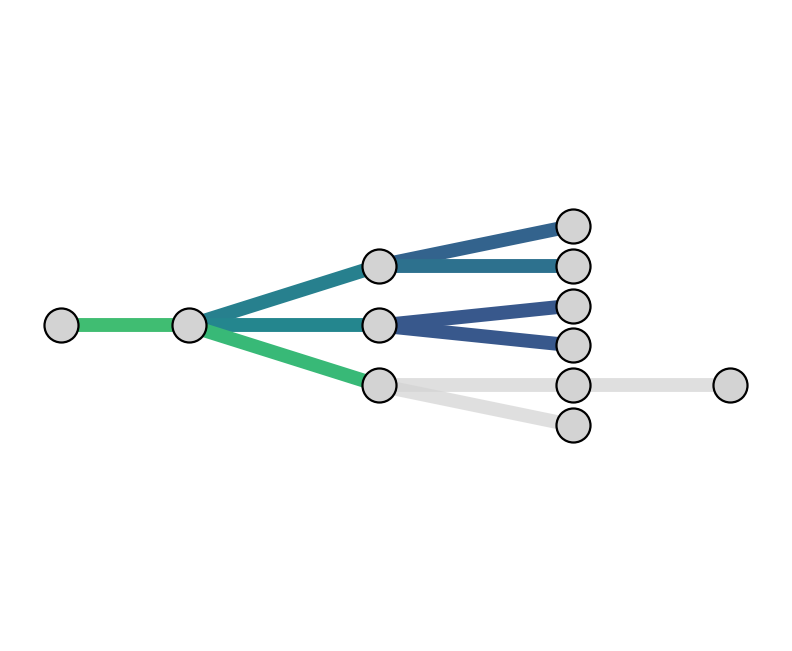

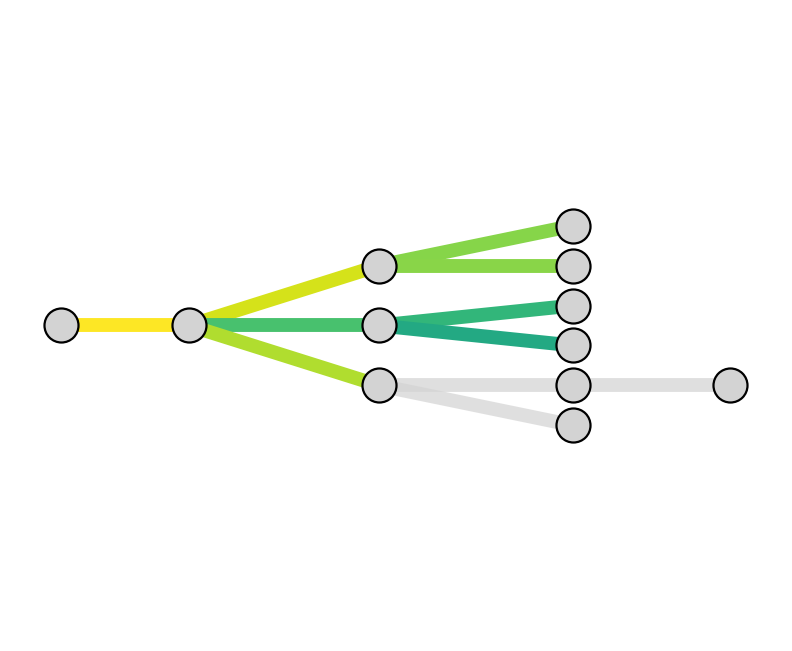

In [121]:
for i in ['weight_tardis', 'weight_scvi']:
    plot_trajectory(
        trj, 
        figsize=(4, 3.25),
        edge_weight_attribute=i,
        title="", 
        edge_vmin=2.1,
        edge_vmax=3.5,
        color_edges_by_weight=True, 
        node_size=150, 
        node_color="lightgray", 
        edge_color='black',
        edge_width=5,
        edge_labels=False,
        edge_label_font_size=5,
        edge_cmap='viridis_r',
        edge_colorbar=False,
        file_name=f"{trajectory_focus}_{i}"
    )

# Figure 3

In [94]:
result_df_boot = pd.read_pickle(os.path.join(temp_move, f"df_boots_fig2_calculations.pkl"))
result_df_boot = result_df_boot[result_df_boot["representation"]=="scvi"]
result_df_boot.reset_index(inplace=True, drop=True)

result_df_main = pd.read_pickle(os.path.join(temp_move, f"df_boots_fig2_calculations_for_individuals.pkl"))

In [95]:
focus_trajectory = "germline"

df_compo = result_df_main[result_df_main["trajectory"] == focus_trajectory]
df_atlas = result_df_boot[result_df_boot["trajectory"] == focus_trajectory]

df_atlas.reset_index(inplace=True, drop=True)
df_compo.reset_index(inplace=True, drop=True)

decompose_method = "2"
input_trajectories_path_litc = os.path.join(temp_move, f"adata_hdca_input_{focus_trajectory}_litc_{decompose_method}.pkl")
with open(input_trajectories_path_litc, 'rb') as _file:
    lit = pickle.load(_file)

trj_size_dict = dict()
for trj_name in lit.graph['trajectories']:
    trj_size_dict[trj_name] = len(lit.get_trajectory(trj_name, False).nodes()), len(lit.get_trajectory(trj_name, False).edges())

assert df_compo.shape == df_atlas.shape
for i in range(len(df_compo)):
    i1 = list(df_atlas.iloc[i][["booted_trajectory", "metric"]])
    i2 = list(df_compo.iloc[i][["booted_trajectory", "metric"]])
    assert i1==i2

# df_both

df_both = df_compo.copy()
del df_both["score"]
df_both["score_Component"] = list(df_compo["score"])
df_both["score_Atlas"] = list(df_atlas["score"])
df_both.reset_index(inplace=True, drop=True)
del df_both["anndata_subset"]

def get_winners(row):
    metric = row['metric']
    direction = metric_direction_dict[metric]
    c = row['score_Component']
    a = row['score_Atlas']
    
    if direction == 'increasing':
        if c > a:
            return pd.Series([0, 1])
        elif a > c:
            return pd.Series([1, 0])
        else:
            return pd.Series([0.5, 0.5])
    elif direction == 'decreasing':
        if c < a:
            return pd.Series([0, 1])
        elif a < c:
            return pd.Series([1, 0])
        else:
            return pd.Series([0.5, 0.5])
    else:
        return pd.Series([None, None])  # In case metric not found
df_both[['winner_Component', 'winner_Atlas']] = df_both.apply(get_winners, axis=1)

def get_nodes_edges(row):
    trj_name = row['booted_trajectory']
    len_nodes, len_edges = trj_size_dict[trj_name]
    return pd.Series([len_nodes, len_edges])
df_both[['len_nodes', 'len_edges']] = df_both.apply(get_nodes_edges, axis=1)

label_mapping_o = {
    "adjacency": "Adjacency",
    "embedding": "Embedding",
    "pseudotime": "Pseudotime",
}
df_both["path"] = [label_mapping_o[i] for i in df_both["path"]]

# long_both

id_cols = [
    "decompose_method", "trajectory_class", "trajectory",
    "booted_trajectory", 'len_nodes', 'len_edges', "path", "metric", 
    "trajectory_annotation_column"
]
_df = df_both.reset_index()  
id_cols = ["index"] + id_cols
long_both = (
    pd.wide_to_long(
        _df,                       # the original wide dataframe
        stubnames=["score", "winner"],
        i=id_cols,                # columns that make a unique row
        j="focus",               # new column: 'component' or 'atlas'
        sep="_",                  # underscore separates stub & suffix
        suffix="(Component|Atlas)"  # the two suffix values to capture
    )
    .reset_index()
    .sort_values(id_cols + ["focus"])   # optional tidy ordering
)
del long_both["index"]

replacements = {
    'Pseudotime': 'Cell Order\ncontinuity',
    'Embedding': 'Trajectory\ndominance',
    'Adjacency': 'Topology\nconservation'
}

long_both_p = long_both.pivot(index=["booted_trajectory", "path", "metric"], columns='focus', values='winner')
long_both_p = long_both_p.groupby(level=[0, 1]).mean()
long_both_p.rename(index=replacements, level="path", inplace=True)

long_both_back = (
    long_both_p
        .stack(dropna=False)      # <- dropna=True by default
        .rename('winner')
        .reset_index()            # gives: booted_trajectory, path, metric, focus, winner
)

long_both_back.head()

,booted_trajectory,path,focus,winner
0,germline_subgraph_0,Topology\nconservation,Atlas,0.619048
1,germline_subgraph_0,Topology\nconservation,Component,0.380952
2,germline_subgraph_0,Trajectory\ndominance,Atlas,0.136364
3,germline_subgraph_0,Trajectory\ndominance,Component,0.863636
4,germline_subgraph_0,Cell Order\ncontinuity,Atlas,0.156250


/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_15592/1797141164.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  bp = sns.barplot(
/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_15592/1797141164.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


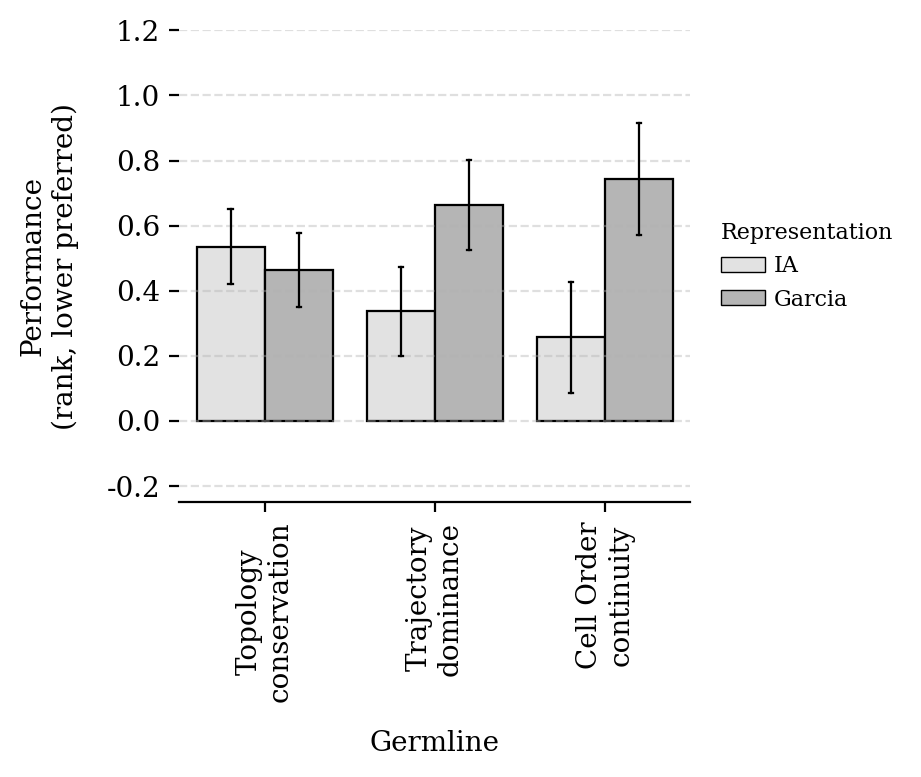

In [97]:
label_mapping = {
    "Atlas": "IA",
    "Component": "Garcia",
}

# match boxplot’s height & per-column width
fig_height = 4
n_cols = long_both_back["focus"].nunique()
col_width = 2.8
fig_width = n_cols * col_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=long_both_back,
    hue="focus",
    y="winner",
    x="path",
    palette=sns.color_palette("Greys", n_colors=len(label_mapping)+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Germline', fontsize=10, labelpad=10)
plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)

ax.set_ylim(-0.25, 1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_mapping.get(l, l) for l in labels]

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    new_labels,
    title="Representation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    alignment="left",
    frameon=False,
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("/Users/kemalinecik/Downloads/fig2fig/comparison_germline_component.pdf")

In [98]:
long_both_germ = long_both_back.copy()

In [99]:
focus_trajectory = "Haem_ref"

df_compo = result_df_main[result_df_main["trajectory"] == focus_trajectory]
df_atlas = result_df_boot[result_df_boot["trajectory"] == focus_trajectory]

df_atlas.reset_index(inplace=True, drop=True)
df_compo.reset_index(inplace=True, drop=True)

decompose_method = "2"
input_trajectories_path_litc = os.path.join(temp_move, f"adata_hdca_input_{focus_trajectory}_litc_{decompose_method}.pkl")
with open(input_trajectories_path_litc, 'rb') as _file:
    lit = pickle.load(_file)

trj_size_dict = dict()
for trj_name in lit.graph['trajectories']:
    trj_size_dict[trj_name] = len(lit.get_trajectory(trj_name, False).nodes()), len(lit.get_trajectory(trj_name, False).edges())

assert df_compo.shape == df_atlas.shape
for i in range(len(df_compo)):
    i1 = list(df_atlas.iloc[i][["booted_trajectory", "metric"]])
    i2 = list(df_compo.iloc[i][["booted_trajectory", "metric"]])
    assert i1==i2

# df_both

df_both = df_compo.copy()
del df_both["score"]
df_both["score_Component"] = list(df_compo["score"])
df_both["score_Atlas"] = list(df_atlas["score"])
df_both.reset_index(inplace=True, drop=True)
del df_both["anndata_subset"]

def get_winners(row):
    metric = row['metric']
    direction = metric_direction_dict[metric]
    c = row['score_Component']
    a = row['score_Atlas']
    
    if direction == 'increasing':
        if c > a:
            return pd.Series([0, 1])
        elif a > c:
            return pd.Series([1, 0])
        else:
            return pd.Series([0.5, 0.5])
    elif direction == 'decreasing':
        if c < a:
            return pd.Series([0, 1])
        elif a < c:
            return pd.Series([1, 0])
        else:
            return pd.Series([0.5, 0.5])
    else:
        return pd.Series([None, None])  # In case metric not found
df_both[['winner_Component', 'winner_Atlas']] = df_both.apply(get_winners, axis=1)

def get_nodes_edges(row):
    trj_name = row['booted_trajectory']
    len_nodes, len_edges = trj_size_dict[trj_name]
    return pd.Series([len_nodes, len_edges])
df_both[['len_nodes', 'len_edges']] = df_both.apply(get_nodes_edges, axis=1)

label_mapping_o = {
    "adjacency": "Adjacency",
    "embedding": "Embedding",
    "pseudotime": "Pseudotime",
}
df_both["path"] = [label_mapping_o[i] for i in df_both["path"]]

# long_both

id_cols = [
    "decompose_method", "trajectory_class", "trajectory",
    "booted_trajectory", 'len_nodes', 'len_edges', "path", "metric", 
    "trajectory_annotation_column"
]
_df = df_both.reset_index()  
id_cols = ["index"] + id_cols
long_both = (
    pd.wide_to_long(
        _df,                       # the original wide dataframe
        stubnames=["score", "winner"],
        i=id_cols,                # columns that make a unique row
        j="focus",               # new column: 'component' or 'atlas'
        sep="_",                  # underscore separates stub & suffix
        suffix="(Component|Atlas)"  # the two suffix values to capture
    )
    .reset_index()
    .sort_values(id_cols + ["focus"])   # optional tidy ordering
)
del long_both["index"]

replacements = {
    'Pseudotime': 'Cell Order\ncontinuity',
    'Embedding': 'Trajectory\ndominance',
    'Adjacency': 'Topology\nconservation'
}

long_both_p = long_both.pivot(index=["booted_trajectory", "path", "metric"], columns='focus', values='winner')
long_both_p = long_both_p.groupby(level=[0, 1]).mean()
long_both_p.rename(index=replacements, level="path", inplace=True)

long_both_back = (
    long_both_p
        .stack(dropna=False)      # <- dropna=True by default
        .rename('winner')
        .reset_index()            # gives: booted_trajectory, path, metric, focus, winner
)

long_both_back.head()

,booted_trajectory,path,focus,winner
0,Haem_ref_subgraph_0,Topology\nconservation,Atlas,0.309524
1,Haem_ref_subgraph_0,Topology\nconservation,Component,0.690476
2,Haem_ref_subgraph_0,Trajectory\ndominance,Atlas,0.545455
3,Haem_ref_subgraph_0,Trajectory\ndominance,Component,0.454545
4,Haem_ref_subgraph_0,Cell Order\ncontinuity,Atlas,0.500000


/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_15592/1985277090.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  bp = sns.barplot(
/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_15592/1985277090.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


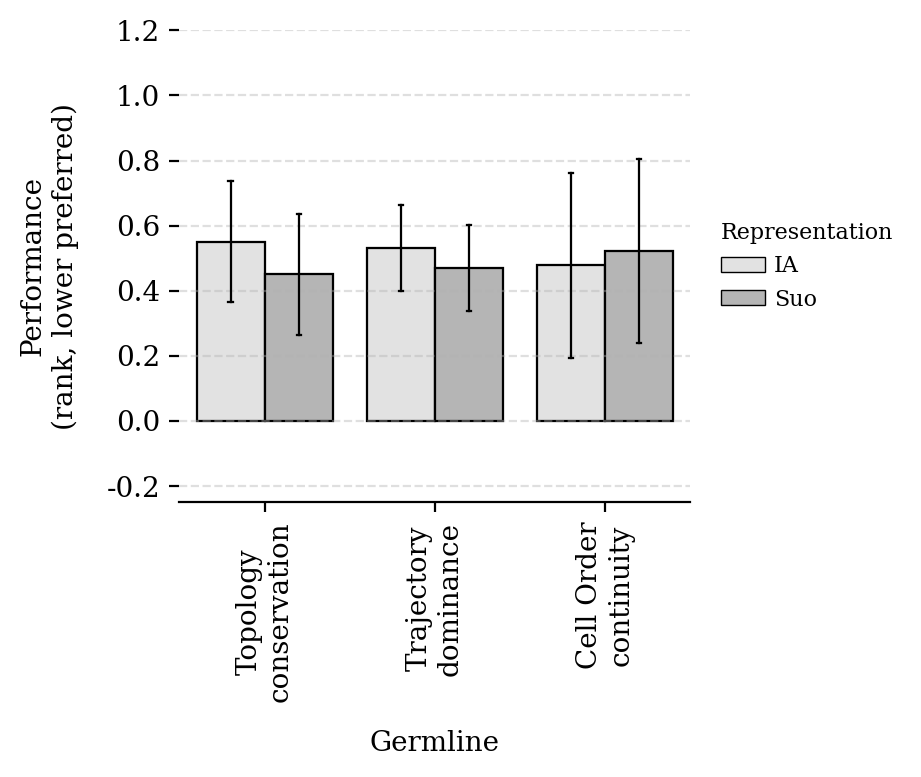

In [100]:
label_mapping = {
    "Atlas": "IA",
    "Component": "Suo",
}

# match boxplot’s height & per-column width
fig_height = 4
n_cols = long_both_back["focus"].nunique()
col_width = 2.8
fig_width = n_cols * col_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=long_both_back,
    hue="focus",
    y="winner",
    x="path",
    palette=sns.color_palette("Greys", n_colors=len(label_mapping)+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Germline', fontsize=10, labelpad=10)
plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)

ax.set_ylim(-0.25, 1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_mapping.get(l, l) for l in labels]

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    new_labels,
    title="Representation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    alignment="left",
    frameon=False,
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("/Users/kemalinecik/Downloads/fig2fig/comparison_hemato_component.pdf")

In [101]:
long_both_haem = long_both_back.copy()

In [102]:
long_both_haem["trajectory_class"] = "Hematopoietic\nLineage"
long_both_germ["trajectory_class"] = "Germline"
long_both2 = pd.concat([long_both_haem, long_both_germ])
long_both2.reset_index(drop=True, inplace=True)

/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_15592/2076327749.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  bp = sns.barplot(
/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_15592/2076327749.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


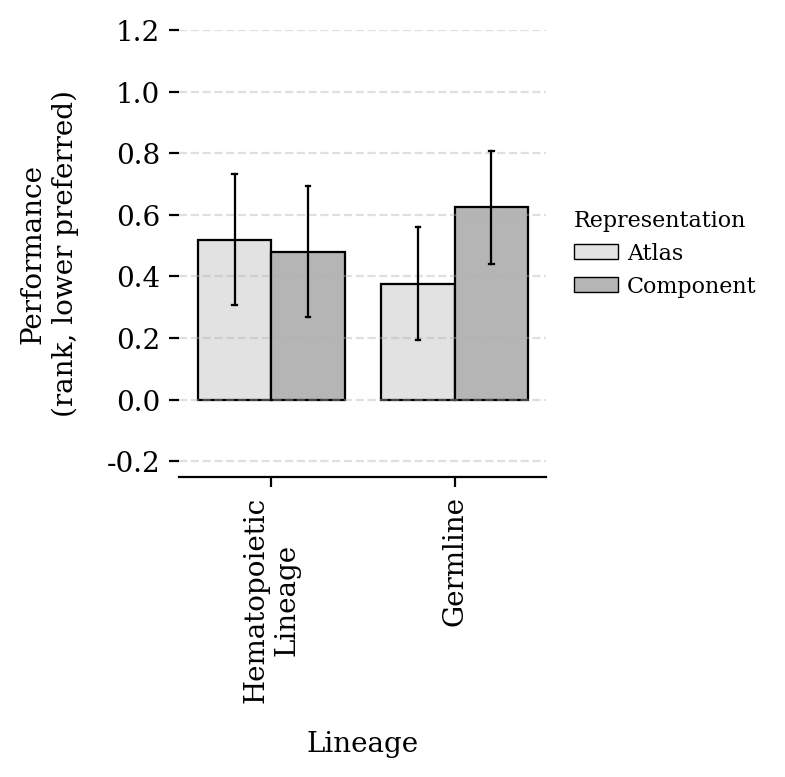

In [103]:
label_mapping = {
    "Atlas": "Atlas",
    "Component": "Component",
}

# match boxplot’s height & per-column width
fig_height = 4
n_cols = long_both2["focus"].nunique()
col_width = 2.4
fig_width = n_cols * col_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=long_both2,
    hue="focus",
    y="winner",
    x="trajectory_class",
    palette=sns.color_palette("Greys", n_colors=len(label_mapping)+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Lineage', fontsize=10, labelpad=10)
plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)

ax.set_ylim(-0.25, 1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_mapping.get(l, l) for l in labels]

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    new_labels,
    title="Representation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    alignment="left",
    frameon=False,
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("/Users/kemalinecik/Downloads/fig2fig/comparison_germline_hemato_both.pdf")

In [104]:
import scvelo as scv
import cellrank as cr
import scanpy.external as sce

scv.settings.verbosity = 3
cr.settings.verbosity = 2
sc.settings.verbose = 3

In [105]:
adata_comp = ad.read_h5ad(os.path.join(temp_move, f"anndata_hdca_input_germline_litc_comparison_comp.h5ad"))
adata_atlas = ad.read_h5ad(os.path.join(temp_move, f"anndata_hdca_input_germline_litc_comparison_atlas.h5ad"))

In [106]:
display((adata_atlas.shape, adata_comp.shape))
sc.pp.neighbors(adata_atlas, n_neighbors=15)
sc.tl.umap(adata_atlas)
sc.pp.neighbors(adata_comp, n_neighbors=15)
sc.tl.umap(adata_comp)

((11001, 28), (10940, 24))

In [107]:
(
    df_hdca_component_adata_paths,
    df_hdca_lvl3_adata_paths,
    out_df,
    ground_truth_trajectories,
    ground_truth_trajectories_annotation_level,
    trajectory_subset_dict
) = load_pickle_bundle(os.path.join(temp_move, "_experiment_development_atlas_helper_pickle_bundle.pkl"))

In [108]:
def cr_calc(adata_cr, root_cell_type, i, ann_levl, knn=15):
    sc.tl.pca(adata_cr, n_comps=11, svd_solver='arpack')
    sce.tl.palantir(adata_cr, n_components=10, knn=knn)

    root_cells = adata_cr.obs_names[adata_cr.obs[ann_levl] == root_cell_type]
    if len(root_cells) == 0:
        raise ValueError(f"No cells found with {ann_levl!r} == {root_cell_type!r}")
    start_cell = root_cells[i]
    
    pr_res = sce.tl.palantir_results(
        adata_cr,
        early_cell=start_cell,
        ms_data="X_palantir_multiscale",
        knn=knn,
        num_waypoints=1200,
        n_jobs=-1
    )
    adata_cr.obs["palantir_pseudotime"] = pr_res.pseudotime

    pk = cr.kernels.PseudotimeKernel(adata_cr, time_key='palantir_pseudotime')
    pk.compute_transition_matrix()
    return pk    

In [109]:
focus_trajectory = "germline"
ann_lvl = ground_truth_trajectories_annotation_level[focus_trajectory]
pk_adata_atlas = cr_calc(adata_atlas.copy(), root_cell_type = "PGC", i=10, ann_levl=ann_lvl)

Sampling and flocking waypoints...
Time for determining waypoints: 0.011821115016937256 minutes
Determining pseudotime...
Shortest path distances using 15-nearest neighbor graph...
Time for shortest paths: 0.1602837840716044 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/11001 [00:00<?, ?cell/s]

    Finish (0:00:01)


Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:01)
saving figure to file /Users/kemalinecik/Downloads/fig2fig/comparison_germline_atlas_umap.pdf


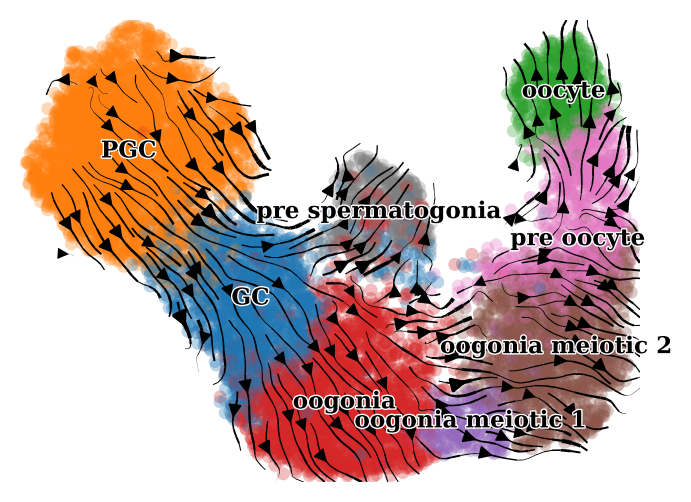

In [110]:
plt.figure(figsize=(4,3))
pk_adata_atlas.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="small", 
                               save="/Users/kemalinecik/Downloads/fig2fig/comparison_germline_atlas_umap.pdf")

In [111]:
pk_adata_comp = cr_calc(adata_comp.copy(), root_cell_type = "PGC", i=10, ann_levl=ann_lvl)

Sampling and flocking waypoints...
Time for determining waypoints: 0.011632716655731202 minutes
Determining pseudotime...
Shortest path distances using 15-nearest neighbor graph...
Time for shortest paths: 0.1473853548367818 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/10940 [00:00<?, ?cell/s]

    Finish (0:00:01)


Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:01)
saving figure to file /Users/kemalinecik/Downloads/fig2fig/comparison_germline_component_umap.pdf


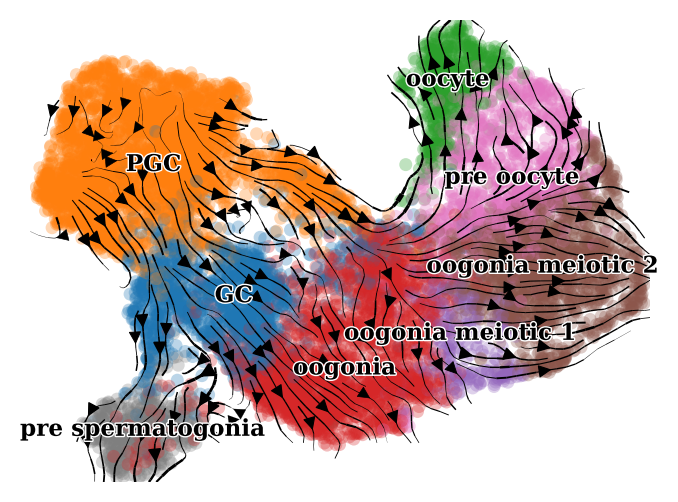

In [112]:
plt.figure(figsize=(4,3))
pk_adata_comp.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="small",
                              save="/Users/kemalinecik/Downloads/fig2fig/comparison_germline_component_umap.pdf")

# Figure 5

In [7]:
import scvelo as scv
import cellrank as cr
import scanpy.external as sce

scv.settings.verbosity = 3
cr.settings.verbosity = 2
sc.settings.verbose = 3

(
    df_hdca_component_adata_paths,
    df_hdca_lvl3_adata_paths,
    out_df,
    ground_truth_trajectories,
    ground_truth_trajectories_annotation_level,
    trajectory_subset_dict
) = load_pickle_bundle(os.path.join(temp_move, "_experiment_development_atlas_helper_pickle_bundle.pkl"))

In [8]:
def cr_calc(adata_cr, root_cell_type, i, ann_levl, knn=15):
    sc.tl.pca(adata_cr, n_comps=11, svd_solver='arpack')
    sce.tl.palantir(adata_cr, n_components=10, knn=knn)

    root_cells = adata_cr.obs_names[adata_cr.obs[ann_levl] == root_cell_type]
    if len(root_cells) == 0:
        raise ValueError(f"No cells found with {ann_levl!r} == {root_cell_type!r}")
    start_cell = root_cells[i]
    
    pr_res = sce.tl.palantir_results(
        adata_cr,
        early_cell=start_cell,
        ms_data="X_palantir_multiscale",
        knn=knn,
        num_waypoints=1200,
        n_jobs=-1
    )
    adata_cr.obs["palantir_pseudotime"] = pr_res.pseudotime

    pk = cr.kernels.PseudotimeKernel(adata_cr, time_key='palantir_pseudotime')
    pk.compute_transition_matrix()
    return pk    




\%%%%%%%%%%%%%%


 scpoli
(76404, 28)
(15280, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.022870914141337077 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.2839118162790934 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9994
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/15280 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:01)
saving figure to file /Users/kemalinecik/Downloads/fig2fig/comparison_models_b_umap_scpoli.svg


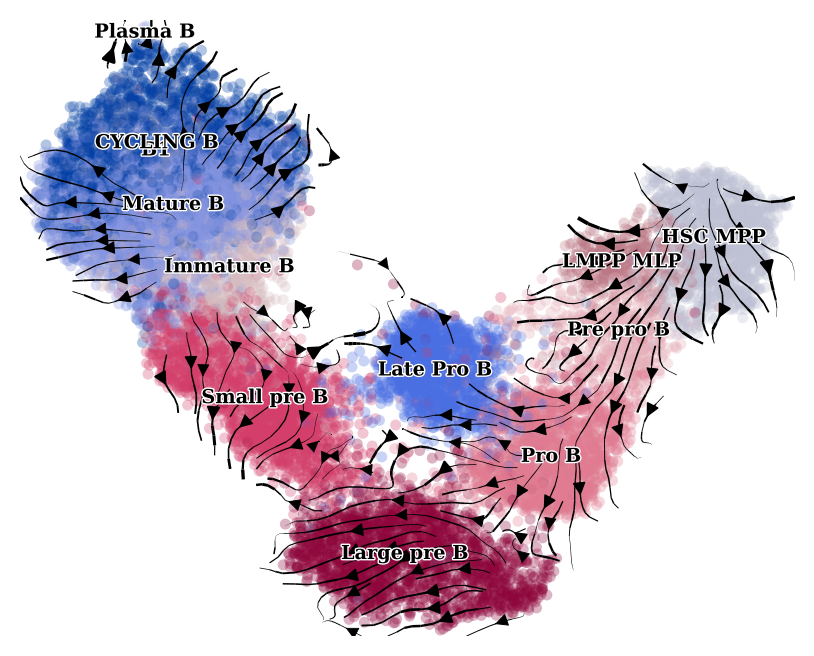




\%%%%%%%%%%%%%%


 scvi
(76404, 28)
(15280, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.017003281911214193 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.22382238308588664 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/15280 [00:00<?, ?cell/s]

    Finish (0:00:01)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:01)
saving figure to file /Users/kemalinecik/Downloads/fig2fig/comparison_models_b_umap_scvi.svg


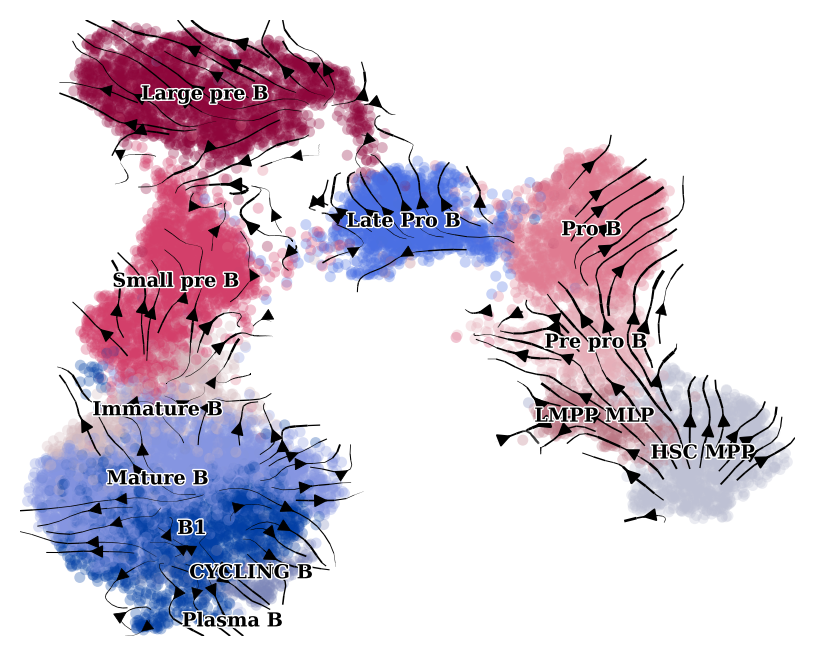

In [9]:
for use_rep in ['scpoli', 'scvi']:
    print("\n\n\n\%%%%%%%%%%%%%%\n\n\n", use_rep)
    adata_atlas = ad.read_h5ad(os.path.join(temp_move, f"anndata_hdca_input_Haem_ref_litc_2_{use_rep}_nodes_b.h5ad"))
    print(adata_atlas.shape)
    sc.pp.subsample(adata_atlas, fraction=0.2)
    print(adata_atlas.shape)
    sc.pp.neighbors(adata_atlas, n_neighbors=15)
    sc.tl.umap(adata_atlas)
    ann_lvl = ground_truth_trajectories_annotation_level["Haem_ref"]
    pk_adata_atlas = cr_calc(adata_atlas.copy(), root_cell_type = "HSC_MPP", i=10, ann_levl=ann_lvl, knn=30)
    plt.figure(figsize=(5,4))
    pk_adata_atlas.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="x-small",
                                   save=f"/Users/kemalinecik/Downloads/fig2fig/comparison_models_b_umap_{use_rep}.svg")
    # break
    del adata_atlas, pk_adata_atlas
    gc.collect()

# Colorbar

In [44]:
from matplotlib import ticker

def create_vertical_colorbar(
    label,
    filename,
    vmin=2.5,
    vmax=3.5,
    cmap='plasma',
    fontsize=10,
    n_ticks=5,
    fig_height=4,
    fig_width=1,
    scale=1.0
):
    """
    Creates and displays a standalone vertical colorbar.

    Parameters:
    - label:        str, label for the colorbar
    - vmin, vmax:   float, data range
    - cmap:         str, colormap name
    - fontsize:     int, for label & tick labels
    - n_ticks:      int, approx number of ticks to show
    - fig_height:   float, base height in inches
    - fig_width:    float, base width in inches
    - scale:        float, scale factor for overall size
    """
    # 1) Make the ScalarMappable
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    # 2) New figure, scaled
    fig = plt.figure(figsize=(fig_width * scale, fig_height * scale))
    # you can tweak these numbers if you want more/less padding
    cax = fig.add_axes([0.2, 0.05, 0.1, 0.9])

    # 3) Draw the colorbar
    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation='vertical'
    )

    # 4) Automatic “nice” locators + re‐draw
    cbar.locator = ticker.MaxNLocator(nbins=n_ticks)
    cbar.update_ticks()

    # 5) Force one‐decimal formatting
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # 6) Label & style
    cbar.set_label(label, fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize)
    
    plt.subplots_adjust(left=0.03, right=0.97, top=0.97, bottom=0.15)
    
    plt.savefig(f"/Users/kemalinecik/Downloads/fig2fig/{filename}.pdf")

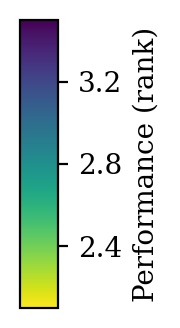

In [48]:
create_vertical_colorbar("Performance (rank)", filename = "colorbar_performance_rank", 
                         cmap="viridis_r", n_ticks=4, fig_height=2, fig_width=2.4, scale=0.8, fontsize=10, vmin=2.1, vmax=3.5)